# Paper — Figures & Validation

In [1]:
# ============================================================
# SHARED SETUP
# ============================================================
import warnings; warnings.filterwarnings("ignore")
import os, re, glob
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib as mpl
import lightgbm as lgb
from lightgbm import early_stopping
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from scipy.stats import wilcoxon
from block_split import block_split
import shap

mpl.rcParams.update({"font.size": 10, "axes.spines.top": False, "axes.spines.right": False,
                     "savefig.bbox": "tight"})

BS, TF, VF, GAP, MDL, THR = 50, 0.2, 0.25, 10, 15, 0.5
CLUSTERS = [1, 2, 3, 4, 5]
C_SHAP, C_NOSHAP = "#D55E00", "#0072B2"

STATION_LABELS = {
    'PRCP_CA002300902':'PRCP_C1','PRCP_GLE00147001':'PRCP_G','PRCP_NOE00105467':'PRCP_N1',
    'PRCP_SV000020107':'PRCP_S1','PRCP_USW00026533':'PRCP_U1','SNWD_CA002300902':'SNWD_C1',
    'SNWD_NO000001026':'SNWD_N2','SNWD_USW00026533':'SNWD_U1','TMAX_CA002200675':'TMAX_C2',
    'TMAX_FI000007501':'TMAX_F','TMAX_JNM00001001':'TMAX_JM','TMAX_RSM00020087':'TMAX_R1',
    'TMAX_SV000001008':'TMAX_S2','TMAX_USW00026533':'TMAX_U1','TMIN_CA002200675':'TMIN_C2',
    'TMIN_JNM00001001':'TMIN_JM','TMIN_NOE00104443':'TMIN_N3','TMIN_RSM00021931':'TMIN_R2',
    'TMIN_SV000001008':'TMIN_S2','SNOW_USW00026616':'SNOW_U2','SNOW_USW00027502':'SNOW_U3',
}
INDEX_LABELS = {'amon':'AMO','nao':'NAO','ao':'AO','nino3':'Nino3','nino34':'Nino3.4',
                'nino12':'Nino1.2','pdo':'PDO','soi':'SOI','tpi':'TPI'}  # FLOW_4 kept as-is

def label(v): 
    return STATION_LABELS.get(v, INDEX_LABELS.get(v, v))
def strip_lag(c): 
    return re.sub(r"\(t[-+]?\d+\)", "", str(c)).strip()
def label_lag(f):
    b = strip_lag(f); lag = re.search(r"\(t[-+]?\d+\)", str(f))
    return label(b) + (lag.group(0) if lag else "")

def block_indices(n):
    dev_idx, test_idx, _ = block_split(n, block_size=BS, test_fraction=TF, gap=GAP)
    tr_rel, va_rel, _ = block_split(len(dev_idx), block_size=BS, test_fraction=VF, gap=GAP)
    return dev_idx[tr_rel], dev_idx[va_rel], test_idx

def results_glob(cluster, case):
    return f"c{cluster}/results_tele_shap*" if case == "shap" else f"no_shap/c{cluster}_p/results_tele_noshap*"

def load_run_masks(glob_pattern, n_features):
    masks = []
    for folder in sorted(glob.glob(glob_pattern)):
        if os.path.basename(folder.rstrip("/")).startswith("no_"):
            continue
        sol_path = os.path.join(folder, "best_solution.csv")
        if not os.path.exists(sol_path):
            continue
        sol = pd.read_csv(sol_path, header=None).values.flatten()
        if len(sol) == n_features:
            masks.append(sol.astype(int))
    return np.array(masks) if masks else None

def consensus_mask(masks, threshold_fraction=THR):
    stack = masks.sum(axis=0)
    min_votes = max(1, int(np.ceil(threshold_fraction * masks.shape[0])))
    return stack >= min_votes

def fit_lgbm(X_tr, y_tr, X_va, y_va):
    params = {"max_bin": 512, "learning_rate": 0.05, "boosting_type": "gbdt",
              "objective": "regression", "metric": "rmse", "num_leaves": 10,
              "verbose": -1, "min_data_in_leaf": MDL, "boost_from_average": True}
    return lgb.train(params, lgb.Dataset(X_tr, label=y_tr), num_boost_round=10000,
                     valid_sets=[lgb.Dataset(X_va, label=y_va)],
                     callbacks=[early_stopping(50, verbose=False)])

def load_cluster(cluster):
    df = pd.read_csv(f"combined_data6_tel12_t_{cluster}.csv")
    y = df.iloc[:, -1]; X = df.iloc[:, :-1]
    return X, y, X.columns.to_numpy(), X.shape[1]


## Table: post-selection performance (consensus R2, per-run mean +/- std)

In [2]:
rows = []
for cluster in CLUSTERS:
    X, y, feat_names, n_features = load_cluster(cluster)
    tr, va, te = block_indices(len(X))
    y_tr, y_va, y_te = y.iloc[tr].values, y.iloc[va].values, y.iloc[te].values

    for case in ["shap", "noshap"]:
        masks = load_run_masks(results_glob(cluster, case), n_features)
        if masks is None:
            continue
        fm = consensus_mask(masks)
        model = fit_lgbm(X.iloc[tr, fm].values, y_tr, X.iloc[va, fm].values, y_va)
        r2_cons = r2_score(y_te, model.predict(X.iloc[te, fm].values))

        run_r2 = []
        for m in masks:
            mb = m.astype(bool)
            if mb.sum() == 0:
                continue
            mrun = fit_lgbm(X.iloc[tr, mb].values, y_tr, X.iloc[va, mb].values, y_va)
            run_r2.append(r2_score(y_te, mrun.predict(X.iloc[te, mb].values)))
        run_r2 = np.array(run_r2)

        rows.append(dict(cluster=cluster, case=case, n_features=int(fm.sum()),
                         r2_consensus=round(r2_cons, 3),
                         r2_run_mean=round(run_r2.mean(), 3), r2_run_std=round(run_r2.std(), 3)))

performance_df = pd.DataFrame(rows)
display(performance_df)


,cluster,case,n_features,r2_consensus,r2_run_mean,r2_run_std
0,1,shap,6,0.563,0.544,0.069
1,1,noshap,12,0.528,0.540,0.079
2,2,shap,6,0.415,0.358,0.138
3,2,noshap,8,0.098,0.287,0.078
4,3,shap,10,0.630,0.612,0.044
5,3,noshap,8,0.573,0.558,0.059
6,4,shap,7,0.531,0.588,0.040
7,4,noshap,7,0.660,0.637,0.046
8,5,shap,9,0.231,0.296,0.071
9,5,noshap,7,0.236,0.318,0.041


## R2 (SHAP vs plain)

In [ ]:
r2_shap = performance_df.query("case=='shap'").sort_values("cluster")["r2_consensus"].values
r2_plain = performance_df.query("case=='noshap'").sort_values("cluster")["r2_consensus"].values

diff = r2_shap - r2_plain
print(f"R2 SHAP:   {r2_shap}")
print(f"R2 plain:  {r2_plain}")
print(f"Per-cluster diff: {np.round(diff, 3)}")
print(f"Mean diff (all clusters): {diff.mean():+.3f}")
print(f"Mean diff (excluding cluster 2): {diff[[0,2,3,4]].mean():+.3f}")


R2 SHAP:   [0.563 0.415 0.63  0.531 0.231]
R2 plain:  [0.528 0.098 0.573 0.66  0.236]
Per-cluster diff: [ 0.035  0.317  0.057 -0.129 -0.005]
Mean diff (all clusters): +0.055
Mean diff (excluding cluster 2): -0.011


## Table + Figure: external baselines (LASSO, mRMR) — heatmap_methods

In [5]:
baseline_rows = []
for cluster in CLUSTERS:
    X, y, feat_names, n_features = load_cluster(cluster)
    tr, va, te = block_indices(len(X))
    X_tr, X_va, X_te = X.iloc[tr].values, X.iloc[va].values, X.iloc[te].values
    y_tr, y_va, y_te = y.iloc[tr].values, y.iloc[va].values, y.iloc[te].values

    K = int(consensus_mask(load_run_masks(results_glob(cluster, "shap"), n_features)).sum())

    fm_shap = consensus_mask(load_run_masks(results_glob(cluster, "shap"), n_features))
    r2_shap = r2_score(y_te, fit_lgbm(X_tr[:, fm_shap], y_tr, X_va[:, fm_shap], y_va).predict(X_te[:, fm_shap]))

    fm_plain = consensus_mask(load_run_masks(results_glob(cluster, "noshap"), n_features))
    r2_plain = r2_score(y_te, fit_lgbm(X_tr[:, fm_plain], y_tr, X_va[:, fm_plain], y_va).predict(X_te[:, fm_plain]))

    scaler = StandardScaler()
    lasso = LassoCV(cv=5, max_iter=20000, n_jobs=-1, random_state=0).fit(scaler.fit_transform(X_tr), y_tr)
    mask_lasso = lasso.coef_ != 0
    r2_lasso = r2_score(y_te, fit_lgbm(X_tr[:, mask_lasso], y_tr, X_va[:, mask_lasso], y_va).predict(X_te[:, mask_lasso])) if mask_lasso.sum() >= 1 else np.nan

    from mrmr import mrmr_regression
    selected = mrmr_regression(X=pd.DataFrame(X_tr, columns=feat_names), y=pd.Series(y_tr), K=K, show_progress=False)
    mask_mrmr = np.isin(feat_names, selected)
    r2_mrmr = r2_score(y_te, fit_lgbm(X_tr[:, mask_mrmr], y_tr, X_va[:, mask_mrmr], y_va).predict(X_te[:, mask_mrmr]))

    baseline_rows.append(dict(cluster=cluster, K=K,
                              plain=round(r2_plain, 3), plain_k=int(fm_plain.sum()),
                              shap=round(r2_shap, 3), shap_k=int(fm_shap.sum()),
                              lasso=round(r2_lasso, 3), lasso_k=int(mask_lasso.sum()),
                              mrmr=round(r2_mrmr, 3), mrmr_k=int(mask_mrmr.sum())))

baseline_df = pd.DataFrame(baseline_rows)
display(baseline_df)
print("\nMean R2:", {c: round(baseline_df[c].mean(), 3) for c in ["plain", "shap", "lasso", "mrmr"]})


,cluster,K,plain,plain_k,shap,shap_k,lasso,lasso_k,mrmr,mrmr_k
0,1,6,0.528,12,0.563,6,0.564,26,0.458,6
1,2,6,0.098,8,0.415,6,0.346,54,0.201,6
2,3,10,0.573,8,0.630,10,0.556,48,0.648,10
3,4,7,0.660,7,0.531,7,0.481,62,0.555,7
4,5,9,0.236,7,0.231,9,0.287,105,0.273,9



Mean R2: {'plain': 0.419, 'shap': 0.474, 'lasso': 0.447, 'mrmr': 0.427}


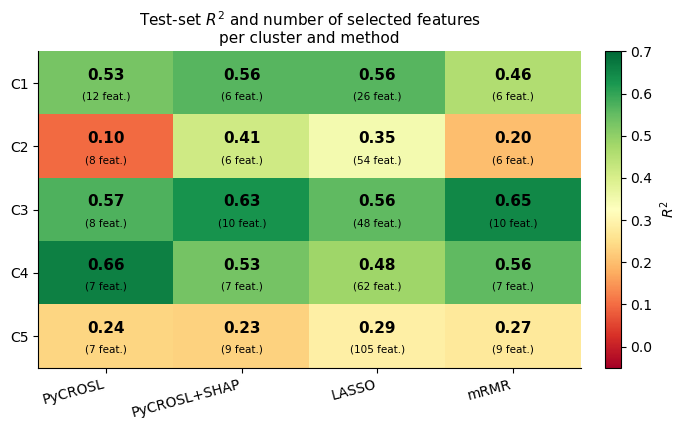

In [6]:
# --- Figure: heatmap_methods.pdf ---
methods = [("plain", "PyCROSL"), ("shap", "PyCROSL+SHAP"), ("lasso", "LASSO"), ("mrmr", "mRMR")]
M = baseline_df[[m[0] for m in methods]].values
K_annot = baseline_df[[m[0] + "_k" for m in methods]].values.astype(int)

fig, ax = plt.subplots(figsize=(7, 4.4))
im = ax.imshow(M, cmap="RdYlGn", vmin=-0.05, vmax=0.7, aspect="auto")
ax.set_xticks(range(4)); ax.set_xticklabels([m[1] for m in methods], rotation=15, ha="right")
ax.set_yticks(range(5)); ax.set_yticklabels([f"C{c}" for c in CLUSTERS])
for i in range(5):
    for j in range(4):
        ax.text(j, i - 0.12, f"{M[i,j]:.2f}", ha="center", va="center", fontsize=11, fontweight="bold")
        ax.text(j, i + 0.22, f"({K_annot[i,j]} feat.)", ha="center", va="center", fontsize=7.5)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="$R^2$")
ax.set_title("Test-set $R^2$ and number of selected features\nper cluster and method", fontsize=11)
plt.tight_layout()
#plt.savefig("paper_figures/method_comparison/B_heatmap_4methods.pdf", dpi=150)
plt.show()


## Figure: variable-level SHAP importance

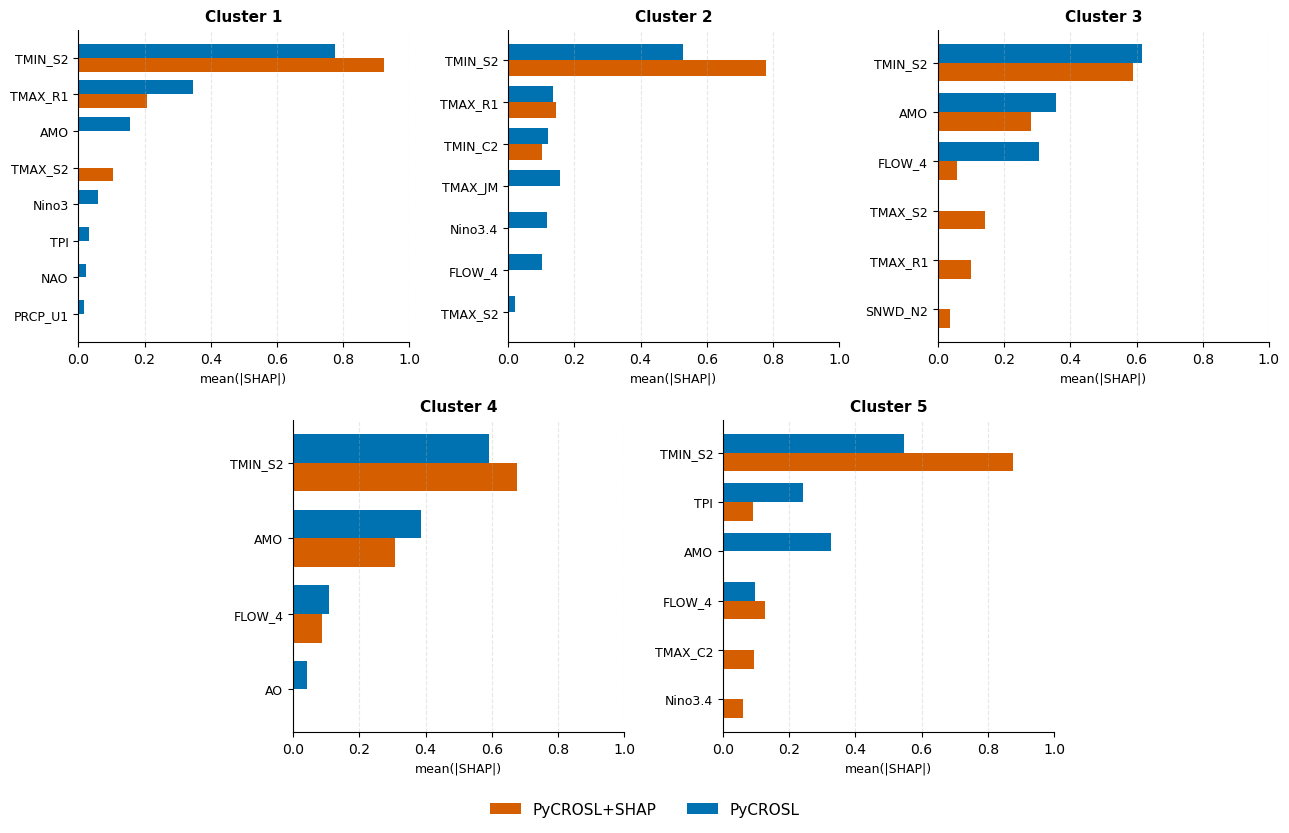

In [7]:
def variable_importance(cluster, case):
    X, y, feat_names, n_features = load_cluster(cluster)
    tr, va, te = block_indices(len(X))
    masks = load_run_masks(results_glob(cluster, case), n_features)
    if masks is None:
        return {}
    fm = consensus_mask(masks); feat = feat_names[fm]
    model = fit_lgbm(X.iloc[tr, fm].values, y.iloc[tr].values, X.iloc[va, fm].values, y.iloc[va].values)
    mean_abs_shap = np.abs(shap.TreeExplainer(model).shap_values(X.iloc[va, fm].values)).mean(0)
    base = np.array([strip_lag(f) for f in feat])
    return {b: mean_abs_shap[base == b].sum() for b in set(base)}

importance_data = {}
xmax = 0
for cluster in CLUSTERS:
    s, n = variable_importance(cluster, "shap"), variable_importance(cluster, "noshap")
    importance_data[cluster] = (s, n)
    xmax = max(xmax, max(list(s.values()) + list(n.values()) + [0]))
xmax = np.ceil(xmax * 10) / 10

fig = plt.figure(figsize=(13, 8.2))
gs = fig.add_gridspec(2, 6)
positions = [gs[0, 0:2], gs[0, 2:4], gs[0, 4:6], gs[1, 1:3], gs[1, 3:5]]
handles = None
for i, cluster in enumerate(CLUSTERS):
    s, n = importance_data[cluster]
    top_vars = sorted(set(s) | set(n), key=lambda v: -(s.get(v, 0) + n.get(v, 0)))[:8]
    labs = [label(v) for v in top_vars]; ys = np.arange(len(top_vars)); h = 0.38
    ax = fig.add_subplot(positions[i])
    b1 = ax.barh(ys + h/2, [s.get(v, 0) for v in top_vars], h, color=C_SHAP, label="PyCROSL+SHAP")
    b2 = ax.barh(ys - h/2, [n.get(v, 0) for v in top_vars], h, color=C_NOSHAP, label="PyCROSL")
    ax.set_yticks(ys); ax.set_yticklabels(labs, fontsize=9); ax.invert_yaxis()
    ax.set_xlim(0, xmax); ax.set_xlabel("mean(|SHAP|)", fontsize=9)
    ax.set_title(f"Cluster {cluster}", fontsize=11, fontweight="bold")
    ax.grid(True, axis="x", ls="--", alpha=.3)
    if handles is None: handles = [b1, b2]
fig.legend(handles, ["PyCROSL+SHAP", "PyCROSL"], loc="lower center", ncol=2, fontsize=11,
          frameon=False, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout(rect=[0, 0.03, 1, 1])
#plt.savefig("paper_figures/importance_v3.pdf", dpi=140)
plt.show()


## Figure: SHAP dependence of representative drivers

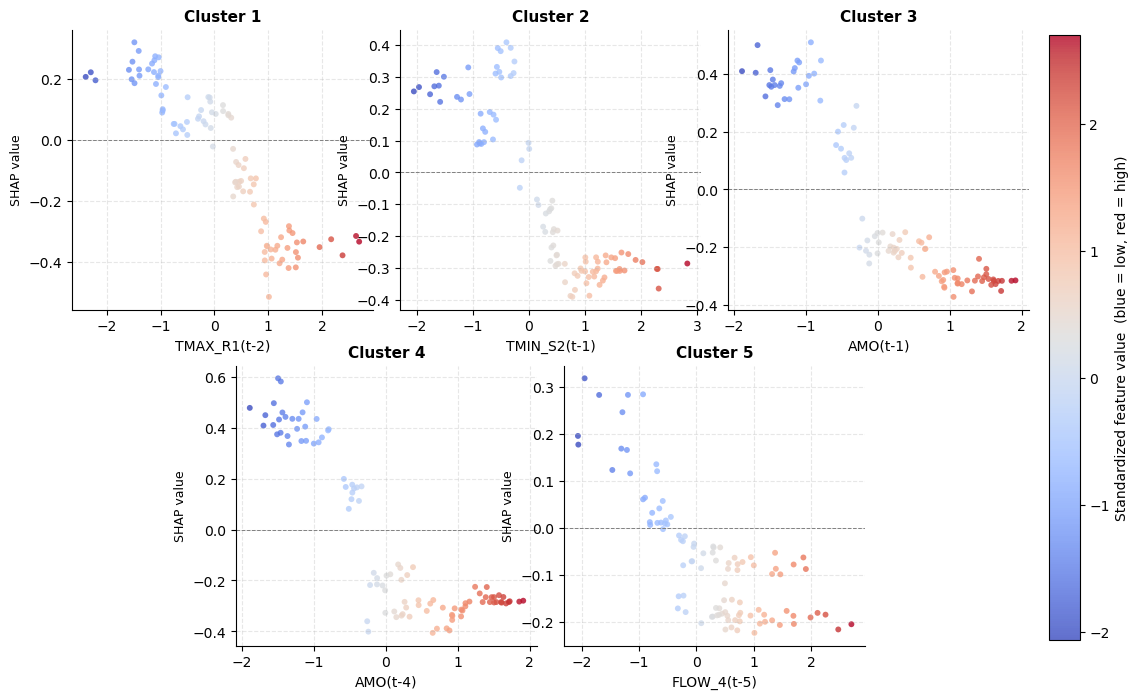

In [ ]:
# one representative predictor per cluster, chosen to span predictor types
DEPENDENCE_CHOICE = {
    1: "TMAX_RSM00020087(t-2)",  # local temperature
    2: "TMIN_SV000001008(t-1)",  # local temperature
    3: "amon(t-1)",              # teleconnection (AMO)
    4: "amon(t-4)",              # teleconnection (AMO), longer lag
    5: "FLOW_4(t-5)",            # river discharge
}

fig = plt.figure(figsize=(13, 8))
gs = fig.add_gridspec(2, 6)
positions = [gs[0, 0:2], gs[0, 2:4], gs[0, 4:6], gs[1, 1:3], gs[1, 3:5]]
scatter = None
for i, cluster in enumerate(CLUSTERS):
    X, y, feat_names, n_features = load_cluster(cluster)
    tr, va, te = block_indices(len(X))
    fm = consensus_mask(load_run_masks(results_glob(cluster, "shap"), n_features))
    feat = list(feat_names[fm])
    model = fit_lgbm(X.iloc[tr, fm].values, y.iloc[tr].values, X.iloc[va, fm].values, y.iloc[va].values)
    shap_values = shap.TreeExplainer(model).shap_values(X.iloc[va, fm].values)
    X_va = X.iloc[va, fm].values

    target = DEPENDENCE_CHOICE[cluster]
    k = feat.index(target) if target in feat else int(np.argmax(np.abs(shap_values).mean(0)))

    ax = fig.add_subplot(positions[i])
    scatter = ax.scatter(X_va[:, k], shap_values[:, k], c=X_va[:, k], cmap="coolwarm",
                         s=18, alpha=.8, edgecolor="none")
    ax.axhline(0, color="gray", lw=.7, ls="--")
    ax.set_xlabel(label_lag(feat[k]), fontsize=10); ax.set_ylabel("SHAP value", fontsize=9)
    ax.set_title(f"Cluster {cluster}", fontsize=11, fontweight="bold")
    ax.grid(True, ls="--", alpha=.3)
cbar = fig.colorbar(scatter, ax=fig.get_axes(), fraction=0.03, pad=0.02, location="right")
cbar.set_label("Standardized feature value  (blue = low, red = high)", fontsize=10)
#plt.savefig("paper_figures/dependence_v2.pdf", dpi=140)
plt.show()


## Persistence baseline (physical-interpretation section)

In [9]:
persistence_rows = []
for cluster in CLUSTERS:
    X, y, feat_names, n_features = load_cluster(cluster)
    y_vals = y.values
    tr, va, te = block_indices(len(X))
    y_tr, y_te = y_vals[tr], y_vals[te]

    r2_climatology = r2_score(y_te, np.full_like(y_te, y_tr.mean()))

    y_lag1 = np.empty_like(y_vals); y_lag1[0] = np.nan; y_lag1[1:] = y_vals[:-1]
    te_valid = te[te >= 1]
    r2_persistence_1m = r2_score(y_vals[te_valid], y_lag1[te_valid])

    te_valid12 = te[te >= 12]
    r2_persistence_12m = r2_score(y_vals[te_valid12], y_vals[te_valid12 - 12])

    persistence_rows.append(dict(cluster=cluster, r2_climatology=round(r2_climatology, 3),
                                 r2_persistence_1month=round(r2_persistence_1m, 3),
                                 r2_persistence_12month=round(r2_persistence_12m, 3)))

persistence_df = pd.DataFrame(persistence_rows)
display(persistence_df)
print("\nRange persistence 1-month R2:", persistence_df.r2_persistence_1month.min(), "-", persistence_df.r2_persistence_1month.max())
print("Range persistence 12-month R2:", persistence_df.r2_persistence_12month.min(), "-", persistence_df.r2_persistence_12month.max())


,cluster,r2_climatology,r2_persistence_1month,r2_persistence_12month
0,1,-0.005,0.925,0.509
1,2,-0.197,0.976,0.766
2,3,-0.030,0.987,0.828
3,4,-0.006,0.976,0.714
4,5,-0.000,0.972,0.655



Range persistence 1-month R2: 0.925 - 0.987
Range persistence 12-month R2: 0.509 - 0.828
